# Handling Skew, Outliers & Feature Insights - Practice Notebook
### CSE-AI, 2nd Year | NumPy, Pandas, Matplotlib, Seaborn

Before building any AI model we must **clean and understand** the data. This notebook covers three
essential data-preparation skills:

1. **Skew** - is a column lop-sided? How do we fix it?
2. **Outliers** - are there extreme values that distort the analysis? How do we find and handle them?
3. **Feature insights** - what does each column tell us, and how do features relate to the target?

**Dataset `customers.csv`** - 200 customers. Columns: `CustomerID, Age, Gender, Region,
Tenure_months, AnnualIncome_k, MonthlySpend_k, NumPurchases`. Target of interest: **MonthlySpend_k**.


In [1]:
# Run first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customers.csv")   # in Colab, upload the file to /content first
print("Shape:", df.shape)
df.head()


Shape: (200, 8)


,CustomerID,Age,Gender,Region,Tenure_months,AnnualIncome_k,MonthlySpend_k,NumPurchases
0,C001,20,Male,West,17,239,22.8,10
1,C002,54,Male,North,57,808,47.5,8
2,C003,47,Female,South,8,583,35.2,8
3,C004,43,Male,South,49,843,42.1,11
4,C005,55,Male,West,41,1284,64.5,7


# Part 1 - Skewness (is the data lop-sided?)

**Skewness** measures how *asymmetric* a distribution is.
- **Right (positive) skew:** a long tail on the right; a few large values pull the **mean above the median**.
- **Left (negative) skew:** a long tail on the left; mean below median.
- **Symmetric:** mean is approximately equal to median (skew is approximately 0).


## Problem 1 - Detect skew (mean vs median + .skew())
Compute the mean, median and `.skew()` value of `AnnualIncome_k`. From these, decide the direction
of the skew.

In [2]:
inc = df["AnnualIncome_k"]
print("Mean   :", round(inc.mean(), 1))
print("Median :", inc.median())
print("Skew   :", round(inc.skew(), 2))

if inc.skew() > 0.5:
    print("\n-> Mean is well ABOVE median and skew > 0  =>  RIGHT (positive) skew")
elif inc.skew() < -0.5:
    print("\n-> LEFT (negative) skew")
else:
    print("\n-> Roughly symmetric")


Mean   : 551.7
Median : 461.5
Skew   : 4.2

-> Mean is well ABOVE median and skew > 0  =>  RIGHT (positive) skew


## Problem 2 - Visualise the skew
Draw a histogram of income with the mean and median marked, plus a boxplot. The long right tail
confirms the skew.

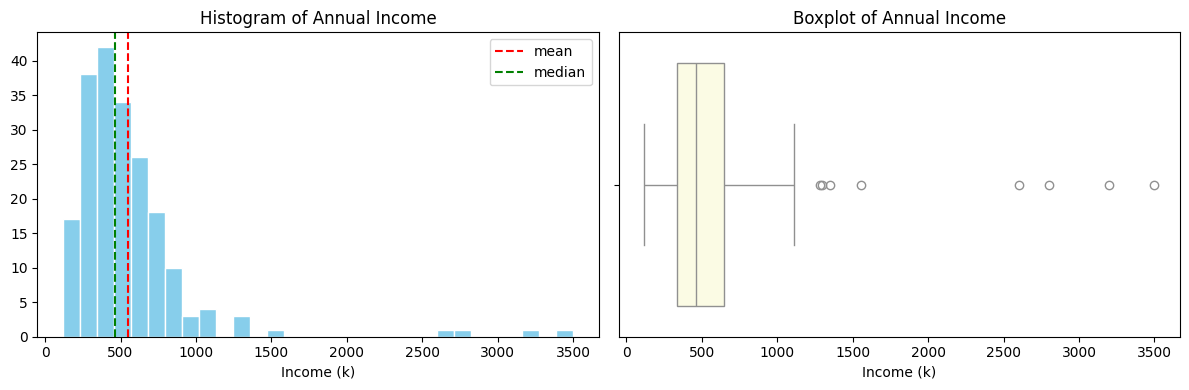

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(inc, bins=30, color="skyblue", edgecolor="white")
ax[0].axvline(inc.mean(),   color="red",   linestyle="--", label="mean")
ax[0].axvline(inc.median(), color="green", linestyle="--", label="median")
ax[0].set_title("Histogram of Annual Income"); ax[0].set_xlabel("Income (k)"); ax[0].legend()

sns.boxplot(x=inc, color="lightyellow", ax=ax[1])
ax[1].set_title("Boxplot of Annual Income"); ax[1].set_xlabel("Income (k)")
plt.tight_layout(); plt.show()
# The bars bunch on the left with a thin tail to the right -> classic right skew.


## Problem 3 - Handle the skew (log transform)
Right skew is commonly fixed with a **log transform**. Apply `np.log1p` (log of 1+x, which is safe
for zeros) to income, and show the skew value dropping toward 0, with before/after histograms.

Skew BEFORE: 4.2
Skew AFTER : 0.65


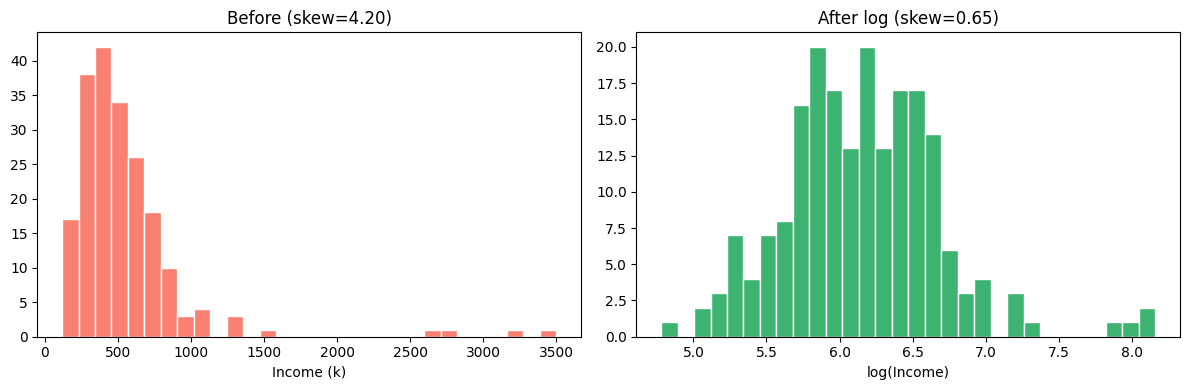

In [4]:
log_income = np.log1p(inc)          # log(1 + income)
print("Skew BEFORE:", round(inc.skew(), 2))
print("Skew AFTER :", round(log_income.skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(inc, bins=30, color="salmon", edgecolor="white")
ax[0].set_title(f"Before (skew={inc.skew():.2f})"); ax[0].set_xlabel("Income (k)")
ax[1].hist(log_income, bins=30, color="mediumseagreen", edgecolor="white")
ax[1].set_title(f"After log (skew={log_income.skew():.2f})"); ax[1].set_xlabel("log(Income)")
plt.tight_layout(); plt.show()
# The transformed data is far more symmetric - better for many ML models.


# Part 2 - Outliers (extreme values)

An **outlier** is a value far away from the rest of the data. Two common ways to detect them:
- **IQR rule:** anything below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.
- **Z-score rule:** anything more than 3 standard deviations from the mean.


## Problem 4 - Detect outliers with the IQR rule
Use the IQR method on `AnnualIncome_k`. Print the bounds and list the outlier customers.

In [5]:
Q1, Q3 = inc.quantile(0.25), inc.quantile(0.75)
IQR = Q3 - Q1
low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Normal range: {low:.0f} to {high:.0f}")

iqr_outliers = df[(inc < low) | (inc > high)]
print(f"\nFound {len(iqr_outliers)} outliers:")
print(iqr_outliers[["CustomerID","AnnualIncome_k"]].to_string(index=False))


Q1=335.0, Q3=647.5, IQR=312.5
Normal range: -134 to 1116

Found 8 outliers:
CustomerID  AnnualIncome_k
      C005            1284
      C047            1351
      C059            2800
      C077            1554
      C161            1294
      C172            2600
      C185            3500
      C194            3200


## Problem 5 - Detect outliers with the Z-score rule
Compute the z-score of each income = (value - mean) / std, using NumPy. Flag customers with
`|z| > 3`. Compare the count with the IQR method.

In [6]:
z = (inc - inc.mean()) / inc.std()      # how many std devs from the mean
df_z = df.assign(Zscore=z.round(2))
z_outliers = df_z[np.abs(df_z["Zscore"]) > 3]
print(f"Z-score outliers (|z| > 3): {len(z_outliers)}")
print(z_outliers[["CustomerID","AnnualIncome_k","Zscore"]].to_string(index=False))
print("\n(IQR flagged", len(iqr_outliers), "- the two methods often differ slightly.)")


Z-score outliers (|z| > 3): 4
CustomerID  AnnualIncome_k  Zscore
      C059            2800    5.22
      C172            2600    4.76
      C185            3500    6.85
      C194            3200    6.15

(IQR flagged 8 - the two methods often differ slightly.)


## Problem 6 - Handle outliers (capping / clipping)
Rather than delete them, we can **cap** extreme values at the IQR bounds (this is called
*winsorizing*). Create a cleaned income column and compare boxplots before and after.

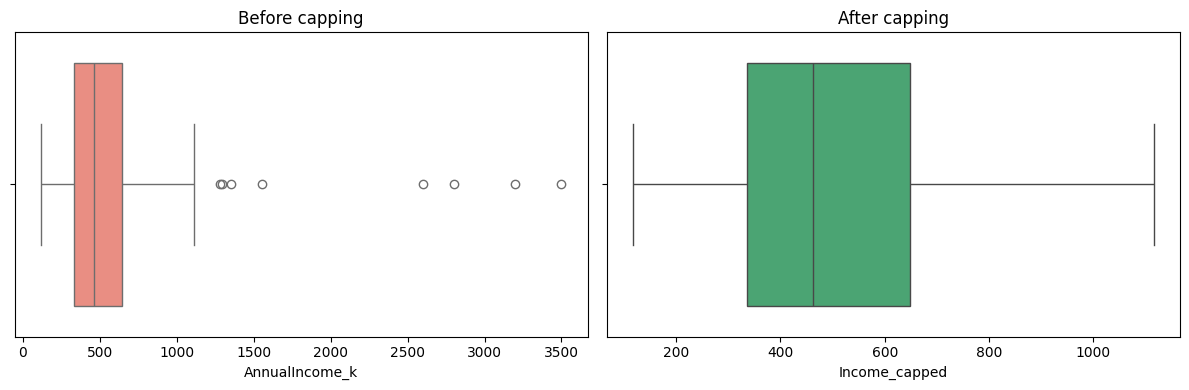

Max income before: 3500 -> after capping: 1116.25


In [7]:
df["Income_capped"] = inc.clip(lower=low, upper=high)   # squeeze values into the normal range

fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x=inc, color="salmon", ax=ax[0]);            ax[0].set_title("Before capping")
sns.boxplot(x=df["Income_capped"], color="mediumseagreen", ax=ax[1]); ax[1].set_title("After capping")
plt.tight_layout(); plt.show()

print("Max income before:", inc.max(), "-> after capping:", df["Income_capped"].max())
# Capping keeps the customer in the data but stops the extreme value from distorting averages.


# Part 3 - Feature Insights (understanding the columns)

Feature insight means learning what each column tells us and how features relate to the target
(here **MonthlySpend_k**). Three common techniques: correlation, group comparisons, and creating
new features.


## Problem 7 - Correlation insight (what drives spending?)
Find how strongly each numeric feature correlates with `MonthlySpend_k`, and draw a heatmap of all
numeric features.

Correlation with MonthlySpend:
 AnnualIncome_k    0.96
Age               0.10
Tenure_months    -0.10
NumPurchases     -0.14
Name: MonthlySpend_k, dtype: float64


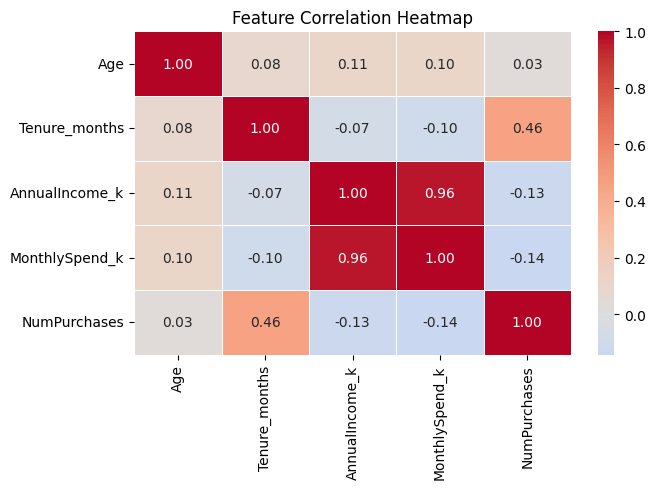


Strongest driver of spending: AnnualIncome_k


In [8]:
num = df[["Age","Tenure_months","AnnualIncome_k","MonthlySpend_k","NumPurchases"]]
target_corr = num.corr()["MonthlySpend_k"].drop("MonthlySpend_k").sort_values(ascending=False)
print("Correlation with MonthlySpend:\n", target_corr.round(2))

plt.figure(figsize=(7,5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=.5)
plt.title("Feature Correlation Heatmap"); plt.tight_layout(); plt.show()
print("\nStrongest driver of spending:", target_corr.idxmax())


## Problem 8 - Group insight (compare segments)
Use `groupby` to compare average income and spend across **Region**, and average spend by
**Gender**. Plot average spend by region.

Average by Region:
         AnnualIncome_k  MonthlySpend_k
Region                                
East             580.3            29.2
North            601.0            30.3
South            548.7            27.4
West             478.9            24.9

Average spend by Gender:
 Gender
Female    28.7
Male      27.3
Name: MonthlySpend_k, dtype: float64


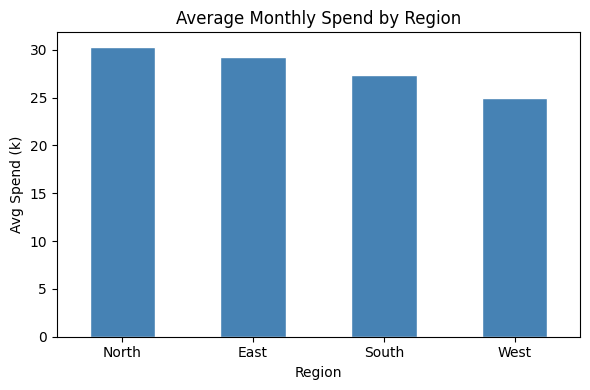

In [9]:
by_region = df.groupby("Region")[["AnnualIncome_k","MonthlySpend_k"]].mean().round(1)
print("Average by Region:\n", by_region)
print("\nAverage spend by Gender:\n", df.groupby("Gender")["MonthlySpend_k"].mean().round(1))

by_region["MonthlySpend_k"].sort_values(ascending=False).plot(
    kind="bar", figsize=(6,4), color="steelblue", edgecolor="white")
plt.title("Average Monthly Spend by Region"); plt.ylabel("Avg Spend (k)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## Problem 9 - Feature engineering (create new features)
Create two new features that give more insight:
1. `SpendPerPurchase` = MonthlySpend / NumPurchases.
2. `IncomeBand` = income grouped into Low / Medium / High with `pd.cut`.
Then show average spend in each income band.

In [10]:
df["SpendPerPurchase"] = (df["MonthlySpend_k"] / df["NumPurchases"]).round(2)
df["IncomeBand"] = pd.cut(df["AnnualIncome_k"],
                          bins=[0, 400, 800, df["AnnualIncome_k"].max()],
                          labels=["Low", "Medium", "High"])

print("New columns preview:")
print(df[["CustomerID","MonthlySpend_k","NumPurchases","SpendPerPurchase","IncomeBand"]].head())

print("\nCustomers per income band:")
print(df["IncomeBand"].value_counts())

print("\nAverage monthly spend by income band:")
print(df.groupby("IncomeBand", observed=True)["MonthlySpend_k"].mean().round(1))


New columns preview:
  CustomerID  MonthlySpend_k  NumPurchases  SpendPerPurchase IncomeBand
0       C001            22.8            10              2.28        Low
1       C002            47.5             8              5.94       High
2       C003            35.2             8              4.40     Medium
3       C004            42.1            11              3.83       High
4       C005            64.5             7              9.21       High

Customers per income band:
IncomeBand
Medium    95
Low       83
High      22
Name: count, dtype: int64

Average monthly spend by income band:
IncomeBand
Low       14.5
Medium    29.6
High      71.6
Name: MonthlySpend_k, dtype: float64


---
### Summary
- **Skew:** compare mean vs median and use `.skew()`; fix right skew with a **log transform** (`np.log1p`).
- **Outliers:** detect with the **IQR rule** or **z-scores**; handle by **capping** (clip) or removing.
- **Feature insights:** use **correlation** (what relates to the target), **groupby** (compare segments),
  and **feature engineering** (`pd.cut`, ratios) to create more useful columns.

These are the first steps in every real data / AI project - clean data and understood features lead
to better models.
